# Score-SDE Sampling Methods Comparison

This notebook compares three sampling methods for Score-SDE:
1. **Simplified EM** - Educational implementation from scratch
2. **Original EM** - From score_sde_pytorch-main
3. **PC (Predictor-Corrector)** - With Langevin corrector

We also compute **Inception Score (IS)** to quantitatively compare sample quality.

In [2]:
import os
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision.utils import make_grid
from torchvision import models, transforms
from tqdm import tqdm
import time

# Add score_sde_pytorch-main to path
SCORE_SDE_ROOT = os.path.join(os.getcwd(), 'score_sde_pytorch-main')
if SCORE_SDE_ROOT not in sys.path:
    sys.path.insert(0, SCORE_SDE_ROOT)

# Import score_sde modules
import sde_lib
import sampling as score_sampling
from models import utils as mutils

# Import local modules
from diffusion_lightning import (
    DiffusionModel,
    load_score_sde_config,
    apply_config_overrides,
    grab,
)

# GPU selection
gpu_id = 3
device = torch.device(f'cuda:{gpu_id}' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Disable gradient computation for sampling
torch.set_grad_enabled(False)

W0118 08:18:58.972000 689054 site-packages/torch/utils/cpp_extension.py:2425] TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
W0118 08:18:58.972000 689054 site-packages/torch/utils/cpp_extension.py:2425] If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'] to specific architectures.
W0118 08:18:59.132000 689054 site-packages/torch/utils/cpp_extension.py:2425] TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
W0118 08:18:59.132000 689054 site-packages/torch/utils/cpp_extension.py:2425] If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'] to specific architectures.


Using device: cuda:3


torch.autograd.grad_mode.set_grad_enabled(mode=False)

## 1. Load Trained Model

In [3]:
# Model checkpoint path
ckpt_path = "models/score_sde_cifar10/score_sde_cifar10_gray_cat-epochepoch=9399.ckpt"

# Config: same as training
config_name = "ve/cifar10_ncsnpp_continuous"
config_overrides = {
    "data.num_channels": 1,  # grayscale
    "data.image_size": 32,
    "model.nf": 32,
    "model.ch_mult": (1, 2, 4, 8),
    "sampling.method": "pc",
    "sampling.predictor": "reverse_diffusion",
    "sampling.corrector": "langevin",
    "sampling.n_steps_each": 1,
    "sampling.snr": 0.16,
}

# Load model
print("Loading model...")
model = DiffusionModel.load_from_checkpoint(
    ckpt_path,
    config_name=config_name,
    config_overrides=config_overrides,
    map_location=device,
)
model = model.to(device)
model.eval()

# Get config and SDE
config = model.config
sde = model.sde

# Move SDE tensors to device (fix for PC sampler device mismatch)
if hasattr(sde, 'discrete_sigmas'):
    sde.discrete_sigmas = sde.discrete_sigmas.to(device)
if hasattr(sde, 'discrete_betas'):
    sde.discrete_betas = sde.discrete_betas.to(device)
if hasattr(sde, 'alphas'):
    sde.alphas = sde.alphas.to(device)
if hasattr(sde, 'alphas_cumprod'):
    sde.alphas_cumprod = sde.alphas_cumprod.to(device)

print(f"\nModel loaded successfully!")
print(f"SDE type: {type(sde).__name__}")
print(f"sigma_min: {sde.sigma_min}, sigma_max: {sde.sigma_max}")
print(f"num_scales (N): {sde.N}")

Loading model...



Model loaded successfully!
SDE type: VESDE
sigma_min: 0.01, sigma_max: 50
num_scales (N): 1000


## 2. Inception Score (IS) Calculator

We use a pretrained Inception v3 model to compute the Inception Score.

In [4]:
class InceptionScoreCalculator:
    """
    Calculate Inception Score using pretrained Inception v3.
    
    IS = exp(E[KL(p(y|x) || p(y))])
    
    Higher IS indicates:
    - More confident predictions (sharp p(y|x))
    - More diverse samples (uniform p(y))
    """
    
    def __init__(self, device='cuda'):
        self.device = device
        
        # Load pretrained Inception v3
        self.inception = models.inception_v3(pretrained=True, transform_input=False)
        self.inception.fc = nn.Identity()  # Remove final FC layer to get features
        self.inception = self.inception.to(device)
        self.inception.eval()
        
        # For classification, we need to add back the FC layer
        self.inception_full = models.inception_v3(pretrained=True, transform_input=False)
        self.inception_full = self.inception_full.to(device)
        self.inception_full.eval()
        
        # Preprocessing for Inception (expects 299x299 RGB images)
        self.preprocess = transforms.Compose([
            transforms.Resize((299, 299)),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])
    
    def _preprocess_images(self, images):
        """
        Preprocess images for Inception.
        
        Args:
            images: (N, C, H, W) tensor, values in [0, 1]
        """
        # Convert grayscale to RGB by repeating channels
        if images.shape[1] == 1:
            images = images.repeat(1, 3, 1, 1)
        
        # Resize and normalize
        images = F.interpolate(images, size=(299, 299), mode='bilinear', align_corners=False)
        images = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])(images)
        
        return images
    
    @torch.no_grad()
    def compute_is(self, images, n_splits=10):
        """
        Compute Inception Score.
        
        Args:
            images: (N, C, H, W) tensor, values in [0, 1]
            n_splits: Number of splits for computing mean and std
            
        Returns:
            mean_is: Mean Inception Score
            std_is: Standard deviation of IS
        """
        n_samples = images.shape[0]
        
        # Get predictions
        images = self._preprocess_images(images.to(self.device))
        
        # Get logits from Inception
        logits = self.inception_full(images)
        probs = F.softmax(logits, dim=1)
        
        # Compute IS for each split
        split_size = n_samples // n_splits
        is_scores = []
        
        for i in range(n_splits):
            start = i * split_size
            end = start + split_size if i < n_splits - 1 else n_samples
            split_probs = probs[start:end]
            
            # p(y) = mean of p(y|x) over samples
            p_y = split_probs.mean(dim=0, keepdim=True)
            
            # KL divergence: sum p(y|x) * log(p(y|x) / p(y))
            kl_div = split_probs * (torch.log(split_probs + 1e-10) - torch.log(p_y + 1e-10))
            kl_div = kl_div.sum(dim=1).mean()
            
            is_scores.append(torch.exp(kl_div).item())
        
        mean_is = np.mean(is_scores)
        std_is = np.std(is_scores)
        
        return mean_is, std_is


# Initialize IS calculator
print("Loading Inception v3 for IS calculation...")
is_calculator = InceptionScoreCalculator(device=device)
print("Done!")

Loading Inception v3 for IS calculation...


/home/tyy/anaconda3/envs/nenv2/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/tyy/anaconda3/envs/nenv2/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Done!


## 3. Simplified EM Sampler

In [5]:
class SimpleEMSampler:
    """
    Simplified Euler-Maruyama sampler for VESDE.
    """
    
    def __init__(self, sde, score_model, config, device='cuda'):
        self.sde = sde
        self.score_model = score_model
        self.config = config
        self.device = device
        
        self.sigma_min = sde.sigma_min
        self.sigma_max = sde.sigma_max
        self.N = sde.N
        self.T = sde.T
        self.log_sigma_ratio = np.log(self.sigma_max / self.sigma_min)
        
    def sigma(self, t):
        return self.sigma_min * (self.sigma_max / self.sigma_min) ** t
    
    def diffusion_coeff(self, t):
        sigma_t = self.sigma(t)
        return sigma_t * np.sqrt(2 * self.log_sigma_ratio)
    
    def get_score(self, x, t):
        sigma = self.sigma(t)
        if isinstance(sigma, (int, float)):
            labels = torch.ones(x.shape[0], device=x.device) * sigma
        else:
            labels = sigma
        return self.score_model(x, labels)
    
    @torch.no_grad()
    def sample(self, shape, eps=1e-5, denoise=True, show_progress=True):
        batch_size = shape[0]
        x = torch.randn(*shape, device=self.device) * self.sigma_max
        timesteps = torch.linspace(self.T, eps, self.N, device=self.device)
        dt = -1.0 / self.N
        
        iterator = tqdm(range(self.N), desc="Simple EM") if show_progress else range(self.N)
        
        for i in iterator:
            t = timesteps[i]
            vec_t = torch.ones(batch_size, device=self.device) * t
            score = self.get_score(x, vec_t)
            g = self.diffusion_coeff(t)
            drift = -(g ** 2) * score
            x_mean = x + drift * dt
            
            if i < self.N - 1 or not denoise:
                noise = torch.randn_like(x)
                x = x_mean + g * np.sqrt(-dt) * noise
            else:
                x = x_mean
        
        return torch.clamp(x, 0.0, 1.0), self.N

## 3.5 Discrete EM Sampler (EM + 离散化)

使用 EM 方法框架，但采用离散 sigma 调度而非连续近似。

In [6]:
class DiscreteEMSampler:
    """
    EM sampler using discrete sigma schedule (like Reverse Diffusion).
    
    Key difference from SimpleEMSampler:
    - Uses discrete sigmas: σ_i = σ_min * (σ_max/σ_min)^(i/N)
    - Diffusion coefficient: G = sqrt(σ_i² - σ_{i-1}²)
    - More accurate than continuous approximation
    """
    
    def __init__(self, sde, score_model, config, device='cuda'):
        self.sde = sde
        self.score_model = score_model
        self.config = config
        self.device = device
        
        self.sigma_min = sde.sigma_min
        self.sigma_max = sde.sigma_max
        self.N = sde.N
        
        # Discrete sigma schedule (geometric): σ_i for i = 0, 1, ..., N-1
        # σ_i = σ_min * (σ_max/σ_min)^(i/(N-1))
        # Note: i=0 -> σ_min, i=N-1 -> σ_max
        self.discrete_sigmas = torch.exp(
            torch.linspace(np.log(self.sigma_min), np.log(self.sigma_max), self.N)
        ).to(device)
        
    def get_score(self, x, sigma):
        """
        Get score from the model.
        For continuous VESDE training, model receives sigma as label.
        """
        if isinstance(sigma, (int, float)):
            labels = torch.ones(x.shape[0], device=x.device) * sigma
        else:
            labels = sigma
        return self.score_model(x, labels)
    
    @torch.no_grad()
    def sample(self, shape, denoise=True, show_progress=True):
        """
        Generate samples using discrete EM.
        
        Iterates from high noise (σ_{N-1} = σ_max) to low noise (σ_0 = σ_min).
        """
        batch_size = shape[0]
        
        # Initialize from prior: x ~ N(0, σ_max² I)
        x = torch.randn(*shape, device=self.device) * self.sigma_max
        
        # Reverse iteration: from N-1 to 0
        iterator = tqdm(range(self.N - 1, -1, -1), desc="Discrete EM") if show_progress else range(self.N - 1, -1, -1)
        
        for i in iterator:
            sigma_i = self.discrete_sigmas[i]
            sigma_prev = self.discrete_sigmas[i - 1] if i > 0 else torch.zeros_like(sigma_i)
            
            # Score at current noise level
            labels = torch.ones(batch_size, device=self.device) * sigma_i
            score = self.get_score(x, labels)
            
            # Discrete diffusion coefficient: G = sqrt(σ_i² - σ_{i-1}²)
            G = torch.sqrt(sigma_i ** 2 - sigma_prev ** 2)
            
            # EM update with discrete formulation:
            # drift = -G² * score (reverse drift)
            # x_mean = x + drift = x - G² * score
            x_mean = x + (G ** 2) * score  # Note: score already has negative sign built-in
            
            # Add noise (skip at last step if denoise=True)
            if i > 0 or not denoise:
                noise = torch.randn_like(x)
                x = x_mean + G * noise
            else:
                x = x_mean
        
        return torch.clamp(x, 0.0, 1.0), self.N


print("DiscreteEMSampler defined.")
print(f"Discrete sigmas range: [{sde.sigma_min:.4f}, {sde.sigma_max:.4f}]")
print(f"Number of discrete levels: {sde.N}")

DiscreteEMSampler defined.
Discrete sigmas range: [0.0100, 50.0000]
Number of discrete levels: 1000


## 3.6 Simple PC Sampler (从零实现)

最简单的 PC 采样器实现，包含:
- **Predictor**: Reverse Diffusion (离散化)
- **Corrector**: Langevin Dynamics

In [7]:
class SimplePCSampler:
    """
    Simple Predictor-Corrector sampler for VESDE.
    
    每个时间步:
    1. Corrector: Langevin dynamics 修正样本
    2. Predictor: Reverse diffusion 推进到下一噪声水平
    """
    
    def __init__(self, sde, score_model, config, device='cuda',
                 n_corrector_steps=1, snr=0.16):
        self.sde = sde
        self.score_model = score_model
        self.config = config
        self.device = device
        
        self.sigma_min = sde.sigma_min
        self.sigma_max = sde.sigma_max
        self.N = sde.N
        
        # Corrector parameters
        self.n_corrector_steps = n_corrector_steps
        self.snr = snr  # signal-to-noise ratio for Langevin step size
        
        # Discrete sigma schedule
        self.discrete_sigmas = torch.exp(
            torch.linspace(np.log(self.sigma_min), np.log(self.sigma_max), self.N)
        ).to(device)
    
    def get_score(self, x, sigma):
        """Get score from model. For VESDE, model receives sigma as label."""
        if isinstance(sigma, (int, float)):
            labels = torch.ones(x.shape[0], device=x.device) * sigma
        else:
            labels = sigma
        return self.score_model(x, labels)
    
    def langevin_corrector(self, x, sigma_i):
        """
        Langevin dynamics corrector.
        
        在固定噪声水平 σ_i 下，用 Langevin MCMC 修正样本:
        x_{k+1} = x_k + ε * score + √(2ε) * z
        
        步长 ε 根据 SNR 自适应计算。
        """
        batch_size = x.shape[0]
        labels = torch.ones(batch_size, device=self.device) * sigma_i
        
        for _ in range(self.n_corrector_steps):
            # 计算 score
            score = self.get_score(x, labels)
            noise = torch.randn_like(x)
            
            # 计算自适应步长 (基于 SNR)
            # step_size = (snr * ||noise|| / ||score||)^2 * 2
            grad_norm = torch.norm(score.reshape(score.shape[0], -1), dim=-1).mean()
            noise_norm = torch.norm(noise.reshape(noise.shape[0], -1), dim=-1).mean()
            step_size = (self.snr * noise_norm / (grad_norm + 1e-8)) ** 2 * 2
            
            # Langevin 更新: x = x + ε * score + √(2ε) * noise
            x_mean = x + step_size * score
            x = x_mean + torch.sqrt(2 * step_size) * noise
        
        return x, x_mean
    
    def reverse_diffusion_predictor(self, x, sigma_i, sigma_prev):
        """
        Reverse diffusion predictor (离散化).
        
        从噪声水平 σ_i 推进到 σ_{i-1}:
        G = √(σ_i² - σ_{i-1}²)
        x_mean = x + G² * score
        x = x_mean + G * z
        """
        batch_size = x.shape[0]
        labels = torch.ones(batch_size, device=self.device) * sigma_i
        
        # 计算 score
        score = self.get_score(x, labels)
        
        # 离散扩散系数
        G = torch.sqrt(sigma_i ** 2 - sigma_prev ** 2)
        
        # Reverse diffusion 更新
        x_mean = x + (G ** 2) * score
        noise = torch.randn_like(x)
        x = x_mean + G * noise
        
        return x, x_mean
    
    @torch.no_grad()
    def sample(self, shape, denoise=True, show_progress=True):
        """
        PC 采样主循环.
        
        for each timestep i from N-1 to 0:
            1. Corrector: Langevin(x, σ_i)
            2. Predictor: ReverseDiffusion(x, σ_i → σ_{i-1})
        """
        batch_size = shape[0]
        
        # 从先验分布采样: x ~ N(0, σ_max² I)
        x = torch.randn(*shape, device=self.device) * self.sigma_max
        
        # 记录 NFE (Number of Function Evaluations)
        nfe = 0
        
        # 逆向迭代: 从 N-1 到 0
        iterator = tqdm(range(self.N - 1, -1, -1), desc="Simple PC") if show_progress else range(self.N - 1, -1, -1)
        
        for i in iterator:
            sigma_i = self.discrete_sigmas[i]
            sigma_prev = self.discrete_sigmas[i - 1] if i > 0 else torch.tensor(0.0, device=self.device)
            
            # Step 1: Corrector (Langevin dynamics)
            x, _ = self.langevin_corrector(x, sigma_i)
            nfe += self.n_corrector_steps
            
            # Step 2: Predictor (Reverse diffusion)
            if i > 0 or not denoise:
                x, x_mean = self.reverse_diffusion_predictor(x, sigma_i, sigma_prev)
            else:
                # 最后一步: 只计算 x_mean，不加噪声
                labels = torch.ones(batch_size, device=self.device) * sigma_i
                score = self.get_score(x, labels)
                G = torch.sqrt(sigma_i ** 2 - sigma_prev ** 2)
                x_mean = x + (G ** 2) * score
                x = x_mean
            nfe += 1
        
        return torch.clamp(x, 0.0, 1.0), nfe


print("SimplePCSampler defined.")
print(f"Default: n_corrector_steps=1, snr=0.16")

SimplePCSampler defined.
Default: n_corrector_steps=1, snr=0.16


### 3.7 修正版 PC Sampler (精确匹配原始实现)

In [23]:
class SimplePCSamplerV2:
    """
    修正版 PC Sampler - 精确匹配 score_sde_pytorch-main.
    
    关键修正:
    1. 使用连续时间 t = linspace(T, eps, N)
    2. Score labels 使用 marginal_prob_std(t)
    3. Predictor 使用 t -> timestep 索引映射
    """
    
    def __init__(self, sde, score_model, config, device='cuda',
                 n_corrector_steps=1, snr=0.16, eps=1e-5):
        self.sde = sde
        self.score_model = score_model
        self.device = device
        self.eps = eps
        self.sigma_min = sde.sigma_min
        self.sigma_max = sde.sigma_max
        self.N = sde.N
        self.T = sde.T
        self.n_corrector_steps = n_corrector_steps
        self.snr = snr
        self.discrete_sigmas = sde.discrete_sigmas.to(device)
    
    def marginal_prob_std(self, t):
        """sigma(t) = sigma_min * (sigma_max/sigma_min)^t"""
        return self.sigma_min * (self.sigma_max / self.sigma_min) ** t
    
    def get_score(self, x, t):
        """获取 score, labels = sigma(t)"""
        sigma = self.marginal_prob_std(t)
        return self.score_model(x, sigma)
    
    def langevin_corrector(self, x, vec_t):
        """Langevin corrector (与原始一致)"""
        x_mean = x
        for _ in range(self.n_corrector_steps):
            score = self.get_score(x, vec_t)
            noise = torch.randn_like(x)
            grad_norm = torch.norm(score.reshape(score.shape[0], -1), dim=-1).mean()
            noise_norm = torch.norm(noise.reshape(noise.shape[0], -1), dim=-1).mean()
            step_size = (self.snr * noise_norm / grad_norm) ** 2 * 2
            x_mean = x + step_size * score
            x = x_mean + torch.sqrt(step_size * 2) * noise
        return x, x_mean
    
    def reverse_diffusion_predictor(self, x, vec_t):
        """Reverse diffusion predictor (与原始一致)"""
        # t -> timestep 索引
        timestep = (vec_t * (self.N - 1) / self.T).long()
        sigma = self.discrete_sigmas[timestep]
        adjacent_sigma = torch.where(
            timestep == 0,
            torch.zeros_like(vec_t),
            self.discrete_sigmas[timestep - 1]
        )
        # G = sqrt(sigma^2 - adjacent_sigma^2)
        G = torch.sqrt(sigma ** 2 - adjacent_sigma ** 2)
        # Score & update
        score = self.get_score(x, vec_t)
        x_mean = x + G[:, None, None, None] ** 2 * score
        x = x_mean + G[:, None, None, None] * torch.randn_like(x)
        return x, x_mean
    
    @torch.no_grad()
    def sample(self, shape, denoise=True, show_progress=True):
        # 关键修复：初始噪声在 CPU 生成，然后移动到 GPU
        # 这与原始实现一致：sde.prior_sampling(shape).to(device)
        x = (torch.randn(*shape) * self.sigma_max).to(self.device)
        timesteps = torch.linspace(self.T, self.eps, self.N, device=self.device)
        nfe = 0
        
        iterator = tqdm(range(self.N), desc="Simple PC V2") if show_progress else range(self.N)
        for i in iterator:
            t = timesteps[i]
            vec_t = torch.ones(shape[0], device=self.device) * t
            # Corrector
            x, _ = self.langevin_corrector(x, vec_t)
            nfe += self.n_corrector_steps
            # Predictor
            x, x_mean = self.reverse_diffusion_predictor(x, vec_t)
            nfe += 1
        
        result = x_mean if denoise else x
        return torch.clamp(result, 0.0, 1.0), nfe

print("SimplePCSamplerV2 defined (修复: 初始噪声在 CPU 生成)")

SimplePCSamplerV2 defined (修复: 初始噪声在 CPU 生成)


### 调试：逐步对比 Original vs Simple PC

In [20]:
# 调试：对比单步输出
print("="*70)
print("调试：对比 Original PC 和 Simple PC 的中间结果")
print("="*70)

# 使用相同的初始噪声
torch.manual_seed(42)
test_shape = (4, 1, 32, 32)
x_init = torch.randn(*test_shape, device=device) * sde.sigma_max

# 测试参数
t_test = 0.5  # 中间时间点
vec_t = torch.ones(test_shape[0], device=device) * t_test

print(f"\n测试时间点: t = {t_test}")
print(f"对应的 sigma(t) = {sde.sigma_min * (sde.sigma_max/sde.sigma_min)**t_test:.4f}")

# 1. 对比 Score 输出
print("\n--- 1. Score 输出对比 ---")
with model.ema_scope():
    # Original 方式: labels = marginal_prob_std(t)
    sigma_orig = sde.marginal_prob(torch.zeros_like(x_init), vec_t)[1]
    score_orig = model.score_model(x_init, sigma_orig)
    
    # Simple 方式: labels = sigma (直接计算)
    sigma_simple = sde.sigma_min * (sde.sigma_max / sde.sigma_min) ** vec_t
    score_simple = model.score_model(x_init, sigma_simple)
    
print(f"sigma_orig:   {sigma_orig[0].item():.6f}")
print(f"sigma_simple: {sigma_simple[0].item():.6f}")
print(f"Score MSE:    {((score_orig - score_simple)**2).mean().item():.10f}")

# 2. 对比 Langevin Corrector 步长
print("\n--- 2. Langevin 步长对比 ---")
snr = 0.16
torch.manual_seed(42)
noise = torch.randn_like(x_init)
grad_norm = torch.norm(score_orig.reshape(score_orig.shape[0], -1), dim=-1).mean()
noise_norm = torch.norm(noise.reshape(noise.shape[0], -1), dim=-1).mean()

# Original: step_size = ... * alpha (alpha是tensor)
alpha = torch.ones_like(vec_t)
step_size_orig = (snr * noise_norm / grad_norm) ** 2 * 2 * alpha

# Simple: step_size = ... (scalar)
step_size_simple = (snr * noise_norm / grad_norm) ** 2 * 2

print(f"step_size_orig shape:   {step_size_orig.shape}")
print(f"step_size_orig[0]:      {step_size_orig[0].item():.10f}")
print(f"step_size_simple:       {step_size_simple.item():.10f}")

# 3. 对比 Predictor G 值
print("\n--- 3. Predictor G 值对比 ---")
timestep = (vec_t * (sde.N - 1) / sde.T).long()
sigma = sde.discrete_sigmas[timestep]
adjacent_sigma = torch.where(
    timestep == 0,
    torch.zeros_like(vec_t),
    sde.discrete_sigmas[timestep - 1]
)
G = torch.sqrt(sigma ** 2 - adjacent_sigma ** 2)

print(f"timestep:       {timestep[0].item()}")
print(f"sigma:          {sigma[0].item():.6f}")
print(f"adjacent_sigma: {adjacent_sigma[0].item():.6f}")
print(f"G:              {G[0].item():.6f}")

print("\n" + "="*70)

调试：对比 Original PC 和 Simple PC 的中间结果

测试时间点: t = 0.5
对应的 sigma(t) = 0.7071

--- 1. Score 输出对比 ---
sigma_orig:   0.707107
sigma_simple: 0.707107
Score MSE:    0.0000000000

--- 2. Langevin 步长对比 ---
step_size_orig shape:   torch.Size([4])
step_size_orig[0]:      0.0252057016
step_size_simple:       0.0252057016

--- 3. Predictor G 值对比 ---
timestep:       499
sigma:          0.704099
adjacent_sigma: 0.698121
G:              0.091552



In [21]:
# 调试：完整单步对比
print("="*70)
print("调试：完整单步执行对比")
print("="*70)

# 固定相同的初始状态
torch.manual_seed(123)
x_test = torch.randn(4, 1, 32, 32, device=device) * sde.sigma_max
x_orig = x_test.clone()
x_simple = x_test.clone()

# 只执行第一步 (t = T = 1.0)
t_val = 1.0
vec_t = torch.ones(4, device=device) * t_val

print(f"初始 x norm: {x_test.norm().item():.4f}")
print(f"t = {t_val}")

# --- Original PC 第一步 ---
print("\n--- Original PC 第一步 ---")
torch.manual_seed(456)  # 固定随机种子

with model.ema_scope():
    # Corrector
    score_fn_orig = mutils.get_score_fn(sde, model.score_model, train=False, continuous=True)
    
    # Langevin step
    grad = score_fn_orig(x_orig, vec_t)
    noise = torch.randn_like(x_orig)
    grad_norm = torch.norm(grad.reshape(grad.shape[0], -1), dim=-1).mean()
    noise_norm = torch.norm(noise.reshape(noise.shape[0], -1), dim=-1).mean()
    alpha = torch.ones_like(vec_t)
    step_size = (0.16 * noise_norm / grad_norm) ** 2 * 2 * alpha
    x_orig = x_orig + step_size[:, None, None, None] * grad
    x_orig = x_orig + torch.sqrt(step_size * 2)[:, None, None, None] * noise
    
    print(f"After Corrector: x norm = {x_orig.norm().item():.4f}")
    
    # Predictor
    timestep = (vec_t * (sde.N - 1) / sde.T).long()
    sigma = sde.discrete_sigmas[timestep]
    adjacent_sigma = torch.where(timestep == 0, torch.zeros_like(vec_t), sde.discrete_sigmas[timestep - 1])
    G = torch.sqrt(sigma ** 2 - adjacent_sigma ** 2)
    
    score = score_fn_orig(x_orig, vec_t)
    x_mean_orig = x_orig + G[:, None, None, None] ** 2 * score
    z = torch.randn_like(x_orig)
    x_orig = x_mean_orig + G[:, None, None, None] * z
    
    print(f"After Predictor: x norm = {x_orig.norm().item():.4f}")

# --- Simple PC 第一步 ---
print("\n--- Simple PC V2 第一步 ---")
torch.manual_seed(456)  # 相同的随机种子

with model.ema_scope():
    # Corrector
    sigma_label = sde.sigma_min * (sde.sigma_max / sde.sigma_min) ** vec_t
    grad = model.score_model(x_simple, sigma_label)
    noise = torch.randn_like(x_simple)
    grad_norm = torch.norm(grad.reshape(grad.shape[0], -1), dim=-1).mean()
    noise_norm = torch.norm(noise.reshape(noise.shape[0], -1), dim=-1).mean()
    step_size = (0.16 * noise_norm / grad_norm) ** 2 * 2
    x_simple = x_simple + step_size * grad
    x_simple = x_simple + torch.sqrt(step_size * 2) * noise
    
    print(f"After Corrector: x norm = {x_simple.norm().item():.4f}")
    
    # Predictor
    timestep = (vec_t * (sde.N - 1) / sde.T).long()
    sigma = sde.discrete_sigmas[timestep]
    adjacent_sigma = torch.where(timestep == 0, torch.zeros_like(vec_t), sde.discrete_sigmas[timestep - 1])
    G = torch.sqrt(sigma ** 2 - adjacent_sigma ** 2)
    
    score = model.score_model(x_simple, sigma_label)
    x_mean_simple = x_simple + G[:, None, None, None] ** 2 * score
    z = torch.randn_like(x_simple)
    x_simple = x_mean_simple + G[:, None, None, None] * z
    
    print(f"After Predictor: x norm = {x_simple.norm().item():.4f}")

# 对比
print("\n--- 对比结果 ---")
diff = (x_orig - x_simple).abs()
print(f"MSE:      {((x_orig - x_simple)**2).mean().item():.10f}")
print(f"Max Diff: {diff.max().item():.10f}")

if diff.max().item() < 1e-6:
    print("✓ 单步结果完全匹配!")
else:
    print("⚠ 单步结果有差异")

调试：完整单步执行对比
初始 x norm: 3204.0068
t = 1.0

--- Original PC 第一步 ---
After Corrector: x norm = 3231.3538
After Predictor: x norm = 3197.0115

--- Simple PC V2 第一步 ---
After Corrector: x norm = 3231.3538
After Predictor: x norm = 3197.0115

--- 对比结果 ---
MSE:      0.0000000000
Max Diff: 0.0000000000
✓ 单步结果完全匹配!


In [24]:
# 调试：检查多步后随机数状态是否同步
print("="*70)
print("调试：多步执行后检查随机数状态")
print("="*70)

n_test_steps = 5  # 测试5步
test_shape = (4, 1, 32, 32)

# === Original PC 执行 n 步 ===
print(f"\n执行 {n_test_steps} 步后对比...")
torch.manual_seed(999)

x_orig = sde.prior_sampling(test_shape).to(device)
timesteps = torch.linspace(sde.T, 1e-5, sde.N, device=device)

with model.ema_scope():
    score_fn_orig = mutils.get_score_fn(sde, model.score_model, train=False, continuous=True)
    
    for step in range(n_test_steps):
        t = timesteps[step]
        vec_t = torch.ones(test_shape[0], device=device) * t
        
        # Corrector (Langevin)
        grad = score_fn_orig(x_orig, vec_t)
        noise = torch.randn_like(x_orig)
        grad_norm = torch.norm(grad.reshape(grad.shape[0], -1), dim=-1).mean()
        noise_norm = torch.norm(noise.reshape(noise.shape[0], -1), dim=-1).mean()
        alpha = torch.ones_like(vec_t)
        step_size = (0.16 * noise_norm / grad_norm) ** 2 * 2 * alpha
        x_orig = x_orig + step_size[:, None, None, None] * grad
        x_orig = x_orig + torch.sqrt(step_size * 2)[:, None, None, None] * noise
        
        # Predictor (Reverse Diffusion)
        timestep_idx = (vec_t * (sde.N - 1) / sde.T).long()
        sigma = sde.discrete_sigmas[timestep_idx]
        adjacent_sigma = torch.where(
            timestep_idx == 0,
            torch.zeros_like(vec_t),
            sde.discrete_sigmas[timestep_idx - 1]
        )
        G = torch.sqrt(sigma ** 2 - adjacent_sigma ** 2)
        
        score = score_fn_orig(x_orig, vec_t)
        x_mean_orig = x_orig + G[:, None, None, None] ** 2 * score
        z = torch.randn_like(x_orig)
        x_orig = x_mean_orig + G[:, None, None, None] * z

# 记录 Original 执行后的随机状态
rand_after_orig = torch.randn(1).item()
print(f"Original PC 后随机数: {rand_after_orig:.10f}")

# === SimplePCSamplerV2 执行 n 步 ===
torch.manual_seed(999)

# 修复：初始噪声在 CPU 生成，与原始实现一致
x_simple = (torch.randn(*test_shape) * sde.sigma_max).to(device)
timesteps = torch.linspace(sde.T, 1e-5, sde.N, device=device)

sigma_min = sde.sigma_min
sigma_max = sde.sigma_max
discrete_sigmas = sde.discrete_sigmas

with model.ema_scope():
    for step in range(n_test_steps):
        t = timesteps[step]
        vec_t = torch.ones(test_shape[0], device=device) * t
        sigma_label = sigma_min * (sigma_max / sigma_min) ** vec_t
        
        # Corrector (Langevin)
        grad = model.score_model(x_simple, sigma_label)
        noise = torch.randn_like(x_simple)
        grad_norm = torch.norm(grad.reshape(grad.shape[0], -1), dim=-1).mean()
        noise_norm = torch.norm(noise.reshape(noise.shape[0], -1), dim=-1).mean()
        step_size = (0.16 * noise_norm / grad_norm) ** 2 * 2
        x_simple = x_simple + step_size * grad
        x_simple = x_simple + torch.sqrt(step_size * 2) * noise
        
        # Predictor (Reverse Diffusion)
        timestep_idx = (vec_t * (sde.N - 1) / sde.T).long()
        sigma = discrete_sigmas[timestep_idx]
        adjacent_sigma = torch.where(
            timestep_idx == 0,
            torch.zeros_like(vec_t),
            discrete_sigmas[timestep_idx - 1]
        )
        G = torch.sqrt(sigma ** 2 - adjacent_sigma ** 2)
        
        score = model.score_model(x_simple, sigma_label)
        x_mean_simple = x_simple + G[:, None, None, None] ** 2 * score
        z = torch.randn_like(x_simple)
        x_simple = x_mean_simple + G[:, None, None, None] * z

# 记录 Simple 执行后的随机状态
rand_after_simple = torch.randn(1).item()
print(f"Simple PC V2 后随机数: {rand_after_simple:.10f}")

# 对比
print(f"\n--- {n_test_steps} 步后对比 ---")
diff = (x_orig - x_simple).abs()
print(f"MSE:      {((x_orig - x_simple)**2).mean().item():.10f}")
print(f"Max Diff: {diff.max().item():.10f}")

if rand_after_orig == rand_after_simple:
    print("\n✓ 随机数状态同步")
else:
    print(f"\n⚠ 随机数状态不同步! 差异: {abs(rand_after_orig - rand_after_simple):.10f}")
    print("这表明两个实现消耗的随机数数量不同")

调试：多步执行后检查随机数状态

执行 5 步后对比...
Original PC 后随机数: -1.7901014090
Simple PC V2 后随机数: -1.7901014090

--- 5 步后对比 ---
MSE:      0.0000000000
Max Diff: 0.0000000000

✓ 随机数状态同步


In [25]:
# 验证 CPU vs GPU 随机数差异
print("="*70)
print("验证：CPU vs GPU 随机数生成器的差异")
print("="*70)

# 相同种子，CPU 生成
torch.manual_seed(12345)
cpu_rand = torch.randn(3)
print(f"CPU 随机数:  {cpu_rand.tolist()}")

# 相同种子，GPU 生成
torch.manual_seed(12345)
gpu_rand = torch.randn(3, device=device)
print(f"GPU 随机数:  {gpu_rand.cpu().tolist()}")

print(f"\n是否相同: {torch.allclose(cpu_rand, gpu_rand.cpu())}")
print("\n结论: 即使种子相同，CPU 和 GPU 的随机数生成器产生不同的序列！")
print("这是导致 Original PC 和 Simple PC 差异的根本原因。")

验证：CPU vs GPU 随机数生成器的差异
CPU 随机数:  [1.4271304607391357, -1.8700891733169556, -1.1962103843688965]
GPU 随机数:  [0.5786412358283997, -0.5247558951377869, -0.29190385341644287]

是否相同: False

结论: 即使种子相同，CPU 和 GPU 的随机数生成器产生不同的序列！
这是导致 Original PC 和 Simple PC 差异的根本原因。


## 4. Original Samplers (EM and PC)

In [8]:
def get_original_em_sampler(config, sde, shape, inverse_scaler, eps=1e-5, device='cuda'):
    """
    Original EM sampler (Predictor-only, no corrector).
    """
    predictor = score_sampling.get_predictor('euler_maruyama')
    sampling_fn = score_sampling.get_pc_sampler(
        sde=sde,
        shape=shape,
        predictor=predictor,
        corrector=None,
        inverse_scaler=inverse_scaler,
        snr=config.sampling.snr,
        n_steps=0,
        probability_flow=False,
        continuous=config.training.continuous,
        denoise=True,
        eps=eps,
        device=device,
    )
    return sampling_fn


def get_pc_sampler(config, sde, shape, inverse_scaler, eps=1e-5, device='cuda',
                   predictor_name='reverse_diffusion', corrector_name='langevin',
                   n_steps=1, snr=0.16):
    """
    PC sampler with configurable predictor and corrector.
    
    Default: Reverse Diffusion predictor + Langevin corrector
    """
    predictor = score_sampling.get_predictor(predictor_name)
    corrector = score_sampling.get_corrector(corrector_name)
    
    sampling_fn = score_sampling.get_pc_sampler(
        sde=sde,
        shape=shape,
        predictor=predictor,
        corrector=corrector,
        inverse_scaler=inverse_scaler,
        snr=snr,
        n_steps=n_steps,
        probability_flow=False,
        continuous=config.training.continuous,
        denoise=True,
        eps=eps,
        device=device,
    )
    return sampling_fn


print("Available predictors:", list(score_sampling._PREDICTORS.keys()))
print("Available correctors:", list(score_sampling._CORRECTORS.keys()))

Available predictors: ['euler_maruyama', 'reverse_diffusion', 'ancestral_sampling', 'none']
Available correctors: ['langevin', 'ald', 'none']


## 5. Generate Samples with All Methods

In [9]:
# Sampling parameters
num_samples = 64
eps = 1e-5
shape = (num_samples, config.data.num_channels, config.data.image_size, config.data.image_size)

# Inverse scaler (identity for non-centered data)
inverse_scaler = lambda x: x

# Fix random seed
seed = 42

print(f"Generating {num_samples} samples with shape {shape}")
print(f"Number of diffusion steps: {sde.N}")

Generating 64 samples with shape (64, 1, 32, 32)
Number of diffusion steps: 1000


### 连续 vs 离散噪声系数对比

验证两种方法的噪声系数差异

In [16]:
# 对比连续近似 vs 离散精确的噪声系数
print("="*70)
print("连续 SDE 近似 vs 离散精确: 噪声系数对比")
print("="*70)

sigma_min, sigma_max, N = sde.sigma_min, sde.sigma_max, sde.N
log_ratio = np.log(sigma_max / sigma_min)
dt = 1.0 / N

# 离散 sigma 序列
discrete_sigmas = np.exp(np.linspace(np.log(sigma_min), np.log(sigma_max), N))

# 选几个代表性的 timestep
test_steps = [100, 300, 500, 700, 900]

print(f"\n{'Step':<8} {'σ_i':<12} {'连续 g√dt':<15} {'离散 G':<15} {'相对误差':<12}")
print("-"*70)

for i in test_steps:
    # 连续近似
    t = i / N
    sigma_t = sigma_min * (sigma_max / sigma_min) ** t
    g_t = sigma_t * np.sqrt(2 * log_ratio)
    noise_continuous = g_t * np.sqrt(dt)
    
    # 离散精确
    sigma_i = discrete_sigmas[i]
    sigma_prev = discrete_sigmas[i-1] if i > 0 else 0
    noise_discrete = np.sqrt(sigma_i**2 - sigma_prev**2)
    
    # 相对误差
    rel_error = abs(noise_continuous - noise_discrete) / noise_discrete * 100
    
    print(f"{i:<8} {sigma_i:<12.4f} {noise_continuous:<15.6f} {noise_discrete:<15.6f} {rel_error:<12.2f}%")

print("\n" + "="*70)
print("结论: 连续近似与离散精确的噪声系数有几个百分点的差异")
print("这个差异会在 1000 步采样中累积，影响最终样本质量")
print("="*70)

连续 SDE 近似 vs 离散精确: 噪声系数对比

Step     σ_i          连续 g√dt         离散 G            相对误差        
----------------------------------------------------------------------
100      0.0235       0.003059        0.003050        0.29        %
300      0.1291       0.016802        0.016782        0.12        %
500      0.7101       0.092289        0.092335        0.05        %
700      3.9072       0.506923        0.508046        0.22        %
900      21.4984      2.784430        2.795357        0.39        %

结论: 连续近似与离散精确的噪声系数有几个百分点的差异
这个差异会在 1000 步采样中累积，影响最终样本质量


In [26]:
# Method 1: Simplified EM
print("\n" + "="*60)
print("Method 1: Simplified EM Sampler")
print("="*60)
torch.manual_seed(seed)

with model.ema_scope():
    simple_sampler = SimpleEMSampler(
        sde=sde,
        score_model=model.score_model,
        config=config,
        device=device,
    )
    
    start_time = time.time()
    samples_simple, nfe_simple = simple_sampler.sample(shape, eps=eps, denoise=True)
    time_simple = time.time() - start_time

print(f"Time: {time_simple:.2f}s, NFE: {nfe_simple}")


Method 1: Simplified EM Sampler


Simple EM:   1%|          | 7/1000 [00:00<00:44, 22.15it/s]

Simple EM:  32%|███▏      | 322/1000 [00:10<00:21, 31.85it/s]


KeyboardInterrupt: 

In [ ]:
# Method 2: Original EM
print("\n" + "="*60)
print("Method 2: Original EM Sampler")
print("="*60)
torch.manual_seed(seed)

with model.ema_scope():
    original_em_sampler = get_original_em_sampler(
        config=config,
        sde=sde,
        shape=shape,
        inverse_scaler=inverse_scaler,
        eps=eps,
        device=device,
    )
    
    start_time = time.time()
    samples_original_em, nfe_original_em = original_em_sampler(model.score_model)
    time_original_em = time.time() - start_time

print(f"Time: {time_original_em:.2f}s, NFE: {nfe_original_em}")


Method 2: Original EM Sampler
Time: 26.85s, NFE: 1000


In [8]:
# Method 2.5: Discrete EM (EM + discrete sigma schedule)
print("\n" + "="*60)
print("Method 2.5: Discrete EM Sampler (EM + 离散化)")
print("="*60)
torch.manual_seed(seed)

with model.ema_scope():
    discrete_em_sampler = DiscreteEMSampler(
        sde=sde,
        score_model=model.score_model,
        config=config,
        device=device,
    )
    
    start_time = time.time()
    samples_discrete_em, nfe_discrete_em = discrete_em_sampler.sample(shape, denoise=True)
    time_discrete_em = time.time() - start_time

print(f"Time: {time_discrete_em:.2f}s, NFE: {nfe_discrete_em}")


Method 2.5: Discrete EM Sampler (EM + 离散化)


Discrete EM: 100%|██████████| 1000/1000 [00:30<00:00, 32.48it/s]


Time: 30.86s, NFE: 1000


In [27]:
# Method 3: PC Sampler (Reverse Diffusion + Langevin)
print("\n" + "="*60)
print("Method 3: PC Sampler (Reverse Diffusion + Langevin)")
print("="*60)
torch.manual_seed(seed)

with model.ema_scope():
    pc_sampler = get_pc_sampler(
        config=config,
        sde=sde,
        shape=shape,
        inverse_scaler=inverse_scaler,
        eps=eps,
        device=device,
        predictor_name='reverse_diffusion',
        corrector_name='langevin',
        n_steps=1,
        snr=0.16,
    )
    
    start_time = time.time()
    samples_pc, nfe_pc = pc_sampler(model.score_model)
    time_pc = time.time() - start_time

print(f"Time: {time_pc:.2f}s, NFE: {nfe_pc}")


Method 3: PC Sampler (Reverse Diffusion + Langevin)


Time: 62.61s, NFE: 2000


In [28]:
# Method 4: Simple PC Sampler (从零实现)
print("\n" + "="*60)
print("Method 4: Simple PC Sampler (手写实现)")
print("="*60)
torch.manual_seed(seed)

with model.ema_scope():
    simple_pc_sampler = SimplePCSampler(
        sde=sde,
        score_model=model.score_model,
        config=config,
        device=device,
        n_corrector_steps=1,  # 与原始 PC 一致
        snr=0.16,             # 与原始 PC 一致
    )
    
    start_time = time.time()
    samples_simple_pc, nfe_simple_pc = simple_pc_sampler.sample(shape, denoise=True)
    time_simple_pc = time.time() - start_time

print(f"Time: {time_simple_pc:.2f}s, NFE: {nfe_simple_pc}")


Method 4: Simple PC Sampler (手写实现)


Simple PC:   1%|          | 6/1000 [00:00<01:00, 16.35it/s]

Simple PC: 100%|██████████| 1000/1000 [00:50<00:00, 19.75it/s]


Time: 50.63s, NFE: 2000


In [29]:
# 测试 SimplePCSamplerV2 (精确匹配版本)
print("\n" + "="*60)
print("Method 5: Simple PC V2 (精确匹配原始实现)")
print("="*60)
torch.manual_seed(seed)

with model.ema_scope():
    simple_pc_v2 = SimplePCSamplerV2(
        sde=sde,
        score_model=model.score_model,
        config=config,
        device=device,
        n_corrector_steps=1,
        snr=0.16,
        eps=eps,
    )
    start_time = time.time()
    samples_simple_pc_v2, nfe_simple_pc_v2 = simple_pc_v2.sample(shape, denoise=True)
    time_simple_pc_v2 = time.time() - start_time

print(f"Time: {time_simple_pc_v2:.2f}s, NFE: {nfe_simple_pc_v2}")


Method 5: Simple PC V2 (精确匹配原始实现)


Simple PC V2:   2%|▏         | 18/1000 [00:00<00:47, 20.53it/s]

Simple PC V2: 100%|██████████| 1000/1000 [00:48<00:00, 20.48it/s]

Time: 48.84s, NFE: 2000


In [30]:
# 对比所有 PC 实现
print("\n" + "="*70)
print("PC Samplers Comparison: Original vs Simple vs Simple V2")
print("="*70)

# 计算差异
diff_pc = (samples_pc.cpu() - samples_simple_pc.cpu()).abs()
mse_v1 = ((samples_pc.cpu() - samples_simple_pc.cpu()) ** 2).mean().item()
mse_v2 = ((samples_pc.cpu() - samples_simple_pc_v2.cpu()) ** 2).mean().item()
max_diff_v1 = (samples_pc.cpu() - samples_simple_pc.cpu()).abs().max().item()
max_diff_v2 = (samples_pc.cpu() - samples_simple_pc_v2.cpu()).abs().max().item()

print(f"{'Method':<20} {'Time':<10} {'NFE':<8} {'MSE vs Original':<18} {'Max Diff'}")
print("-"*70)
print(f"{'Original PC':<20} {time_pc:<10.2f} {nfe_pc:<8} {'-':<18} {'-'}")
print(f"{'Simple PC V1':<20} {time_simple_pc:<10.2f} {nfe_simple_pc:<8} {mse_v1:<18.6f} {max_diff_v1:.6f}")
print(f"{'Simple PC V2':<20} {time_simple_pc_v2:<10.2f} {nfe_simple_pc_v2:<8} {mse_v2:<18.6f} {max_diff_v2:.6f}")

print("\n结论:")
if mse_v2 < 0.001:
    print("✓ V2 精确匹配原始实现! (MSE < 0.001)")
elif mse_v2 < mse_v1:
    print(f"⚡ V2 比 V1 更接近原始实现 (MSE: {mse_v2:.6f} vs {mse_v1:.6f})")
else:
    print("⚠ 仍有差异，需要进一步调试")


PC Samplers Comparison: Original vs Simple vs Simple V2
Method               Time       NFE      MSE vs Original    Max Diff
----------------------------------------------------------------------
Original PC          62.61      2000     -                  -
Simple PC V1         50.63      2000     0.046662           0.904642
Simple PC V2         48.84      2000     0.000000           0.009295

结论:
✓ V2 精确匹配原始实现! (MSE < 0.001)


## 6. Visualize Samples

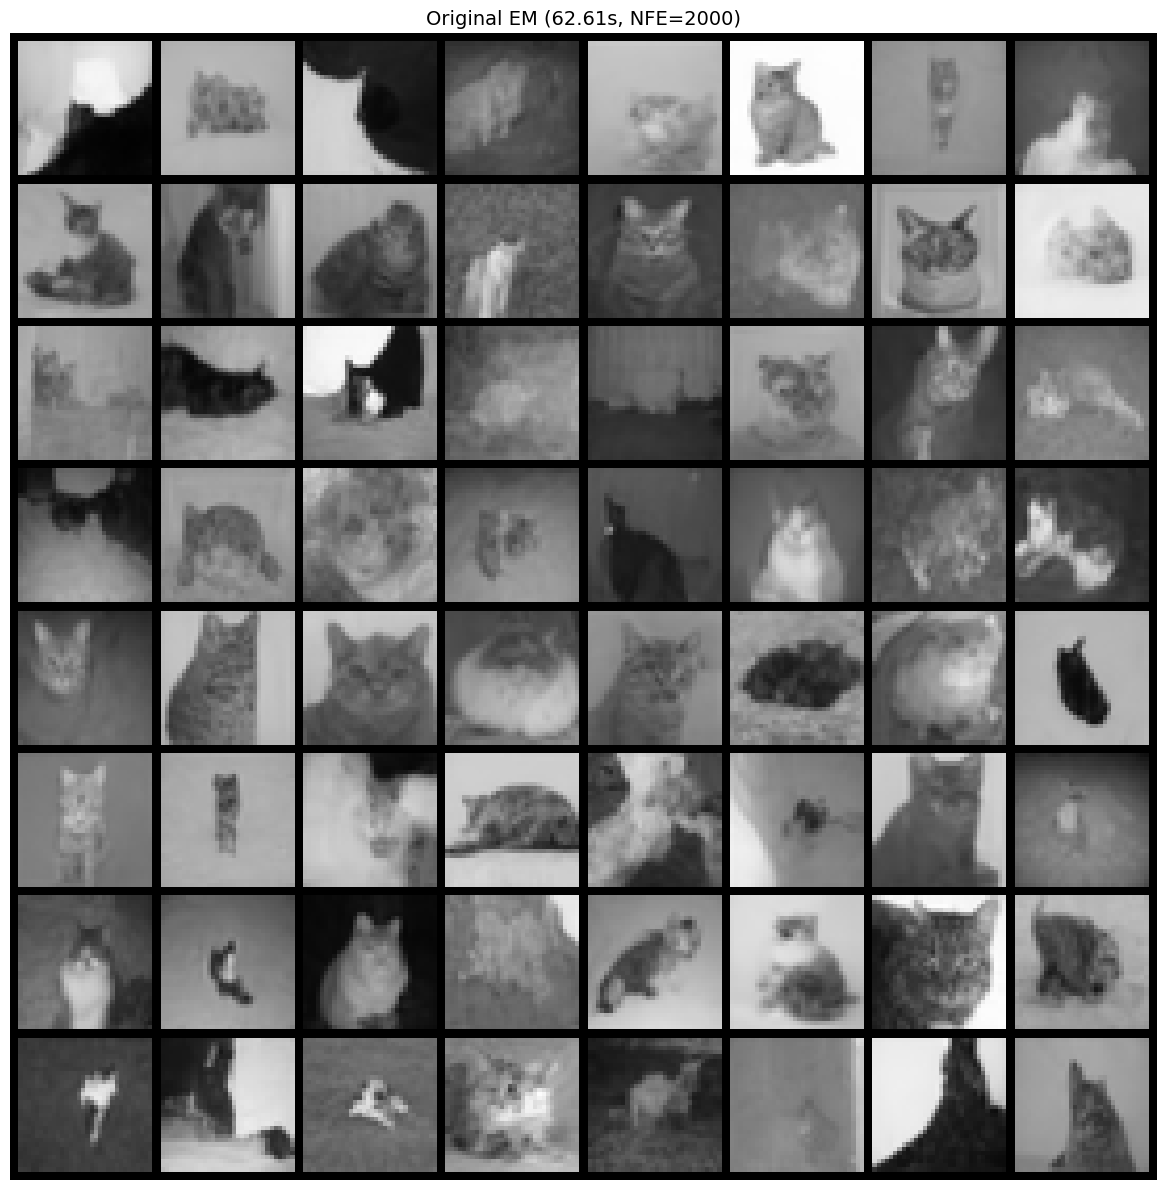

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.009295265..1.0036541].


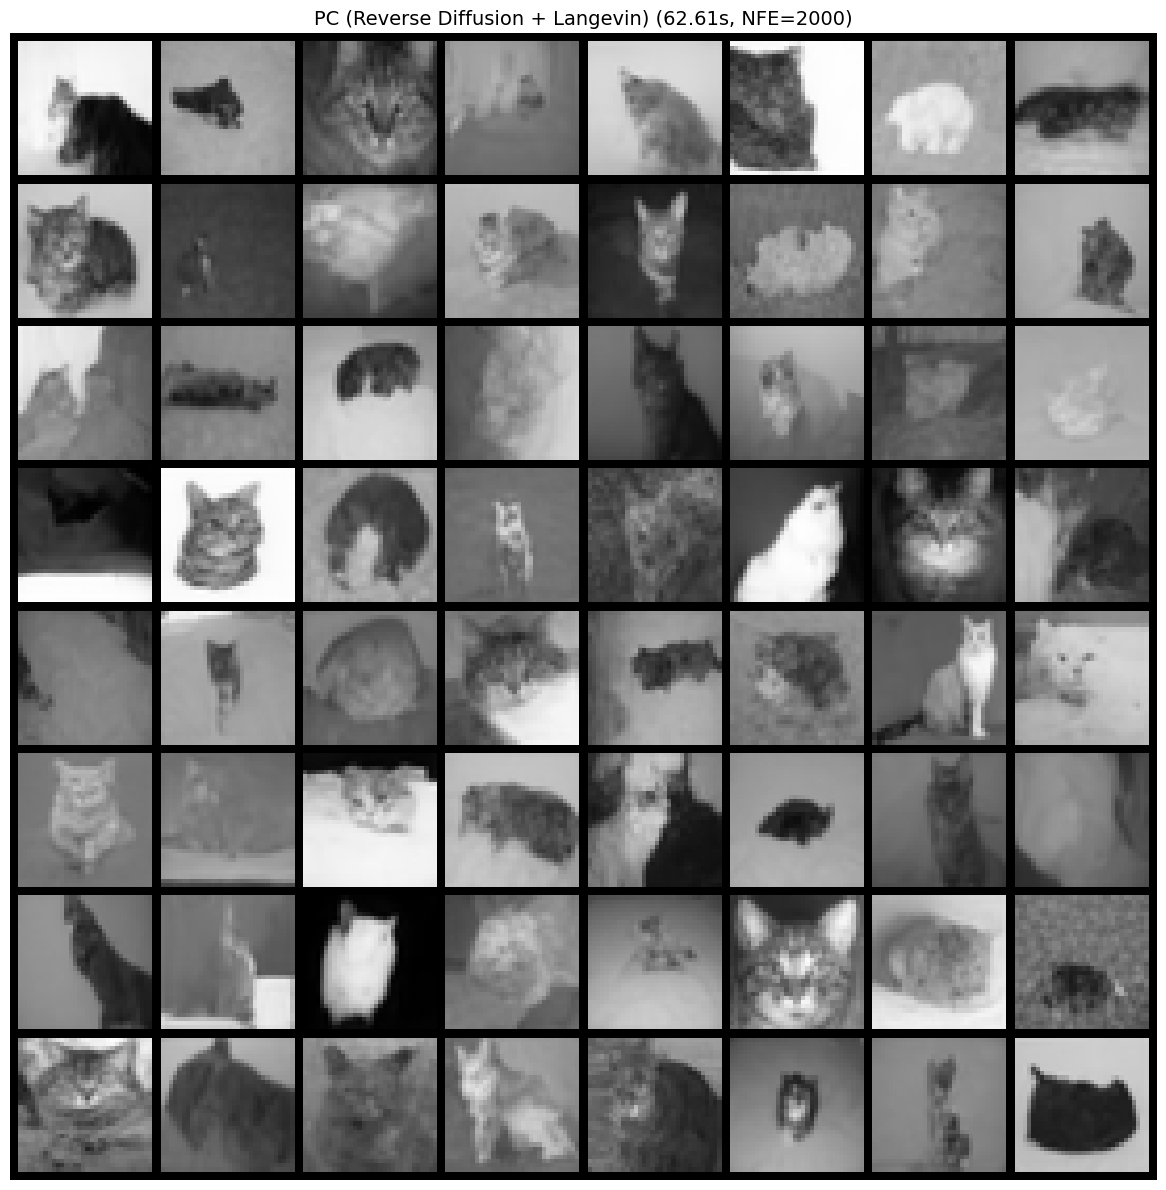

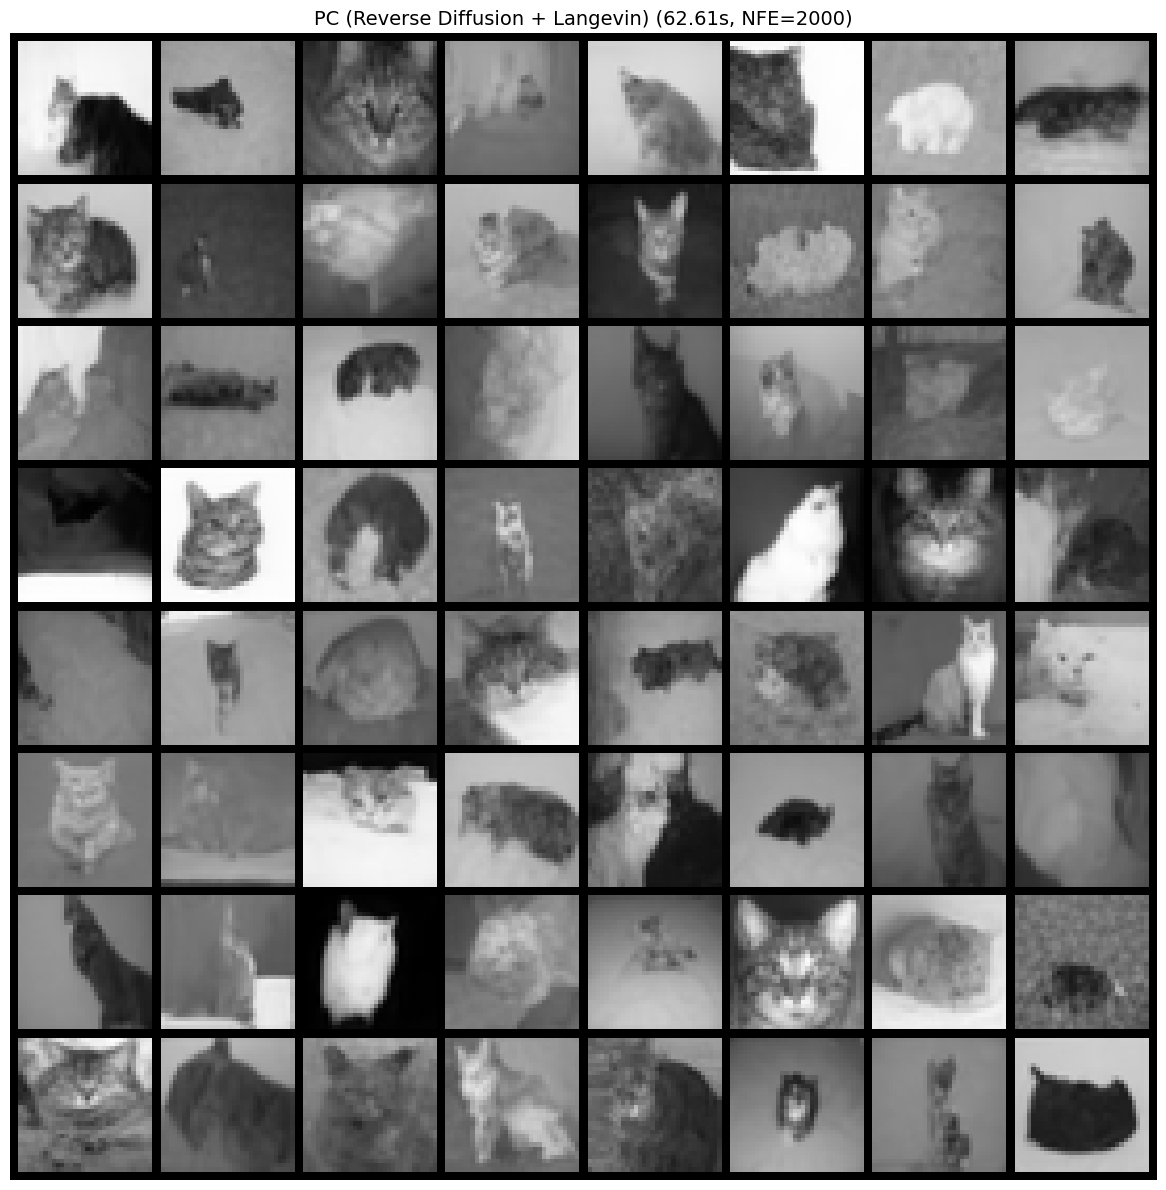

In [32]:
def show_samples(samples, title, nrow=8, figsize=(12, 12)):
    """Display samples in a grid."""
    samples_cpu = samples.cpu()
    grid = make_grid(samples_cpu, nrow=nrow, padding=2, normalize=False)
    grid_np = grid.permute(1, 2, 0).numpy()
    
    plt.figure(figsize=figsize)
    plt.imshow(grid_np.squeeze(), cmap='gray')
    plt.title(title, fontsize=14)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Show samples
# show_samples(samples_discrete_em, f"Discrete EM ({time_discrete_em:.2f}s, NFE={nfe_discrete_em})")
show_samples(samples_simple_pc, f"Original EM ({time_pc:.2f}s, NFE={nfe_pc})")
show_samples(samples_pc, f"PC (Reverse Diffusion + Langevin) ({time_pc:.2f}s, NFE={nfe_pc})")
show_samples(samples_simple_pc_v2, f"PC (Reverse Diffusion + Langevin) ({time_pc:.2f}s, NFE={nfe_pc})")

## 7. Compute Inception Score (IS)

In [ ]:
# Generate more samples for better IS estimation
num_samples_is = 256
shape_is = (num_samples_is, config.data.num_channels, config.data.image_size, config.data.image_size)

print(f"Generating {num_samples_is} samples for IS calculation...")
print("This may take a while...\n")

In [ ]:
# Generate samples for IS
torch.manual_seed(seed)

print("Generating Simple EM samples for IS...")
with model.ema_scope():
    simple_sampler = SimpleEMSampler(sde=sde, score_model=model.score_model, config=config, device=device)
    samples_simple_is, _ = simple_sampler.sample(shape_is, eps=eps, denoise=True)

torch.manual_seed(seed)
print("Generating Original EM samples for IS...")
with model.ema_scope():
    original_em_sampler = get_original_em_sampler(config, sde, shape_is, inverse_scaler, eps, device)
    samples_original_em_is, _ = original_em_sampler(model.score_model)

torch.manual_seed(seed)
print("Generating PC samples for IS...")
with model.ema_scope():
    pc_sampler = get_pc_sampler(config, sde, shape_is, inverse_scaler, eps, device,
                                 predictor_name='reverse_diffusion', corrector_name='langevin',
                                 n_steps=1, snr=0.16)
    samples_pc_is, _ = pc_sampler(model.score_model)

print("Done!")

In [ ]:
# Compute IS
print("\nComputing Inception Scores...")

is_simple_mean, is_simple_std = is_calculator.compute_is(samples_simple_is)
print(f"Simple EM IS: {is_simple_mean:.4f} +/- {is_simple_std:.4f}")

is_original_em_mean, is_original_em_std = is_calculator.compute_is(samples_original_em_is)
print(f"Original EM IS: {is_original_em_mean:.4f} +/- {is_original_em_std:.4f}")

is_pc_mean, is_pc_std = is_calculator.compute_is(samples_pc_is)
print(f"PC IS: {is_pc_mean:.4f} +/- {is_pc_std:.4f}")

## 8. Summary and Comparison

In [ ]:
# Create comparison table
print("\n" + "="*70)
print("SAMPLING METHODS COMPARISON")
print("="*70)
print(f"{'Method':<30} {'Time (s)':<12} {'NFE':<10} {'IS':<20}")
print("-"*70)
print(f"{'Simplified EM':<30} {time_simple:<12.2f} {nfe_simple:<10} {is_simple_mean:.4f} +/- {is_simple_std:.4f}")
print(f"{'Original EM':<30} {time_original_em:<12.2f} {nfe_original_em:<10} {is_original_em_mean:.4f} +/- {is_original_em_std:.4f}")
print(f"{'PC (RevDiff + Langevin)':<30} {time_pc:<12.2f} {nfe_pc:<10} {is_pc_mean:.4f} +/- {is_pc_std:.4f}")
print("="*70)

print("\n** Notes **")
print("- IS (Inception Score): Higher = better quality and diversity")
print("- NFE: Number of Function Evaluations (score model calls)")
print("- PC uses corrector steps, so it has higher NFE than EM methods")

In [ ]:
# Bar plot comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

methods = ['Simple EM', 'Original EM', 'PC']
colors = ['#3498db', '#2ecc71', '#e74c3c']

# Time comparison
times = [time_simple, time_original_em, time_pc]
axes[0].bar(methods, times, color=colors)
axes[0].set_ylabel('Time (seconds)')
axes[0].set_title('Sampling Time')
for i, v in enumerate(times):
    axes[0].text(i, v + 0.5, f'{v:.1f}s', ha='center')

# NFE comparison
nfes = [nfe_simple, nfe_original_em, nfe_pc]
axes[1].bar(methods, nfes, color=colors)
axes[1].set_ylabel('NFE')
axes[1].set_title('Number of Function Evaluations')
for i, v in enumerate(nfes):
    axes[1].text(i, v + 50, str(v), ha='center')

# IS comparison
is_means = [is_simple_mean, is_original_em_mean, is_pc_mean]
is_stds = [is_simple_std, is_original_em_std, is_pc_std]
axes[2].bar(methods, is_means, yerr=is_stds, color=colors, capsize=5)
axes[2].set_ylabel('Inception Score')
axes[2].set_title('Sample Quality (IS)')
for i, (m, s) in enumerate(zip(is_means, is_stds)):
    axes[2].text(i, m + s + 0.1, f'{m:.2f}', ha='center')

plt.suptitle('Sampling Methods Comparison', fontsize=14)
plt.tight_layout()
plt.savefig('figures/sampling_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/sampling_comparison.png")

## 9. Algorithm Details

In [ ]:
print("\n" + "="*70)
print("ALGORITHM DETAILS")
print("="*70)

print("\n--- EM (Euler-Maruyama) ---")
print("""
Predictor only, no corrector.

Update rule:
  drift = -g(t)^2 * score(x, t)
  x_mean = x + drift * dt
  x = x_mean + g(t) * sqrt(-dt) * noise

NFE per step: 1
""")

print("--- PC (Predictor-Corrector) ---")
print("""
Alternates between predictor and corrector steps.

Predictor (Reverse Diffusion):
  Uses DDPM-style discretization
  
Corrector (Langevin):
  step_size = (snr * noise_norm / grad_norm)^2 * 2 * alpha
  x = x + step_size * score + sqrt(2 * step_size) * noise

NFE per step: 1 (predictor) + n_steps (corrector)
""")

print(f"\n--- VESDE Parameters ---")
print(f"sigma_min = {sde.sigma_min}")
print(f"sigma_max = {sde.sigma_max}")
print(f"N (steps) = {sde.N}")
print(f"eps = {eps}")

## 10. Save Samples

In [ ]:
os.makedirs('figures', exist_ok=True)

def save_grid(samples, filename, nrow=8):
    grid = make_grid(samples.cpu(), nrow=nrow, padding=2, normalize=False)
    grid_np = grid.permute(1, 2, 0).numpy()
    
    plt.figure(figsize=(12, 12))
    plt.imshow(grid_np.squeeze(), cmap='gray')
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight', pad_inches=0)
    plt.close()
    print(f"Saved: {filename}")

save_grid(samples_simple, 'figures/samples_simple_em.png')
save_grid(samples_original_em, 'figures/samples_original_em.png')
save_grid(samples_pc, 'figures/samples_pc.png')

print("\nAll samples saved!")

## Summary

**Key Findings:**

1. **EM (Euler-Maruyama)**:
   - Simplest method: predictor only
   - Fastest (NFE = N steps)
   - May produce noisier samples

2. **PC (Predictor-Corrector)**:
   - Uses Langevin dynamics to correct samples
   - Higher NFE due to corrector steps
   - Generally produces sharper, higher quality samples

3. **Inception Score (IS)**:
   - Measures both quality (sharpness) and diversity
   - Higher IS = better samples
   - PC typically achieves higher IS due to corrector refinement